# Anomaly Detection Combining Smart-Meter Data and LV Network Topology

## Objectives

Every anomaly-detection paper worth reading, including the most current ones this notebook cites, still frames the problem the same way it has for a decade: one meter, one baseline, decide if today's reading deviates from it. That framing quietly assumes a customer's own "normal" stays fixed once established, and that an anomaly lives inside one customer's own meter. Neither survives contact with where real LV networks are actually headed. DER adoption is not a one-time event, it is a permanent re-baselining, Chapter 4 already found real archetype drift within a single year. And DER adoption clusters and synchronizes, so a real anomaly can live in how several individually normal customers coincide, not in any one customer's own meter, a structural blind spot no per-customer detector can see by construction.

Four chained questions, each pushing past what the standard framing can answer:

- Does today's per-customer detection paradigm even work, tested honestly with a real feature representation and a real, calibrated threshold instead of a heuristic percentile?
- What happens when the anomaly is not in any one customer, but in how several perfectly normal customers coincide?
- Is the detector itself still trustworthy as the network keeps changing underneath it?
- Is magnitude even the right thing to be watching, or does a customer's own DER behavior, when and how often they export, carry a real, different signal?

By the end you will be able to:

- Detect a real anomaly in a customer's own smart-meter history using a parametric-and-non-parametric ensemble, with a threshold set by split-conformal calibration, not a guessed percentile.
- Show, empirically, that per-customer detection has a real structural blind spot, a coincident event several individually normal customers create together, and build a network-aware alternative that catches it.
- Track whether a detector's own confidence is holding up as DER adoption reshapes the customer population, a real, forward-looking early-warning signal for when a model needs refreshing, not a one-time build assumed to stay valid forever.
- Detect a real behavioral fault, an export pattern's own timing or fragmentation, that a magnitude-based detector alone catches only about half the time.


## Getting the data

This notebook reuses the same real AusNet smart-meter pool Chapters 1 through 5 already vendored, no new fetch step needed:

```bash
uv run python scripts/fetch_part4_ausnet_data.py
```

Section 2 also extends across Chapter 5's own second real network, fetched separately:

```bash
uv run python scripts/fetch_part4_uk_mvlv_data.py
```


In [ ]:
from pathlib import Path

from lets_plot import LetsPlot
import numpy as np
import pandas as pd

LetsPlot.setup_html(isolated_frame=True)
DATA_DIR = Path("../../resources/cvar_flexibility/data/timeseries-lv")

load_data = np.load(DATA_DIR / "Residential load data 30-min resolution.npy")
n_customers, n_days, n_steps = load_data.shape
print(f"load_data: {load_data.shape} (customers, days, half-hours)")

load_data: (342, 365, 48) (customers, days, half-hours)


## Borrow, do not invent

Every detection technique in this notebook already has a name and a track record somewhere else. Patrizi and colleagues compared One-Class SVM, Isolation Forest, and Angle-Based Outlier Detection for real power-quality anomaly detection in 2024, and found that a simple three-sigma control-limit rule can outperform more complex threshold schemes in practice, a real, honest baseline this notebook does not skip past. Labura, Antic, and Capuder combined Isolation Forest with FFT-based frequency-domain features for smart-meter distribution-network anomaly detection in 2025, the direct precedent for pairing a shape-and-frequency feature representation with a non-parametric detector, the same combination this notebook's own Section 1 builds. Li, Zhao, Hu, Botta, Ionescu, and Chen published ECOD in 2023, a genuinely parameter-free, empirical-CDF-based outlier score that has quickly become a strong non-parametric baseline, implemented here directly from the paper's own algorithm rather than pulled from a library, since it is simple enough to earn that treatment.

None of those three papers, or any other found while researching this notebook, address the threshold question honestly. Hennhöfer, Kirsch, and Preisach made exactly that point in early 2026: anomaly-detection systems typically output a score, not a calibrated decision, leaving practitioners to pick a threshold heuristically. This notebook answers that the same way Chapters 3 through 5 already have, three times: split-conformal calibration, not a guessed percentile. A fourth application of the same tool, not a new one.

Oguntola, AbdulQoyum, Madehin, and Adetoro published a hybrid graph-neural-network-and-LSTM framework for topology-aware electricity-theft detection in 2026, real, current precedent for fusing a network's own structure with a detector. Section 2 checks that idea directly against AusNet's own real feeder before deciding whether it earns its place here.


## Section 1: Does per-customer detection even work here?

A bare instantaneous voltage, current, or power reading throws away the shape information that actually separates a real anomaly from ordinary diurnal variation, the same lesson Part 2 of this book already spent a full chapter on for a different signal: Chapter 2's own Feature Engineering found that raw current alone underperforms a real feature representation, the WRG/AWRG pipeline turning a window into a distance-matrix image carrying far more identifying signal than any single reading. The same lesson applies here, on a different signal, at a different frequency.

Every detector in this section runs on a real feature vector, not a raw reading: each customer's own peak-normalized daily shape, the same representation Chapters 4 and 5 already cluster and retrieve on, plus rolling statistics (mean, standard deviation, rate of change, peak-to-trough range) and FFT-magnitude features carrying the moment-to-moment structure a pure shape embedding would miss.


In [ ]:
import sys

sys.path.insert(0, "../..")

from ark.anomaly.features import extract_features

example_profile = load_data[0, 0, :]
example_features = extract_features(example_profile)
print(f"one customer's one day: {example_profile.shape} raw readings -> {example_features.shape} feature vector")

one customer's one day: (48,) raw readings -> (54,) feature vector


### A real self-baseline, not a population comparison

The key question is not whether a reading looks unusual compared to everyone else, but whether it looks unusual compared to the customer's own history. Customers can have very different demand levels, so comparing them to the whole population could make a small household seem abnormal for the same reason as a real fault, and could miss real issues in larger households. AusNet’s data includes 365 days per customer, which is enough to build a baseline for each one. We use 280 days to train the detectors, set aside another block to calibrate the threshold, and keep a separate block to check the false-positive rate before testing with any injected anomalies.


In [ ]:
rng = np.random.default_rng(1)
all_days = np.arange(n_days)
rng.shuffle(all_days)
train_days = all_days[:280]
calibration_days = all_days[280:320]
test_normal_days = all_days[320:340]
anomaly_day_pool = all_days[340:]

print(
    f"{len(train_days)} training days, {len(calibration_days)} calibration days, "
    f"{len(test_normal_days)} held-out normal test days, "
    f"{len(anomaly_day_pool)} real days for injected anomalies"
)

280 training days, 40 calibration days, 20 held-out normal test days, 25 real days for injected anomalies


### Injecting known anomalies, honestly

No real, publicly labeled stuck-meter or communication-dropout data exists for this feeder. Matching the exact discipline Chapter 4 used for its EV-injection test and Chapter 5 used for its new-adopter validation: inject known, realistic anomalies onto real customer data, so detection is checked against ground truth this notebook actually knows, not assumed. Three real failure modes, each grounded in the real literature on smart-meter data quality: a stuck reading held constant for a real block of steps, a communication dropout where the reported reading collapses to zero, and a calibration drift, a gradual multiplicative bias across the day.


In [ ]:
def inject_stuck_reading(profile: np.ndarray, *, rng: np.random.Generator) -> np.ndarray:
    """Hold the reading constant for a real block of steps, a real stuck-meter failure mode."""
    injected = profile.copy()
    start = int(rng.integers(0, 40))
    length = int(rng.integers(6, 12))
    injected[start : start + length] = profile[start]
    return injected


def inject_dropout(profile: np.ndarray, *, rng: np.random.Generator) -> np.ndarray:
    """A real communication-dropout window: the reported reading collapses to zero."""
    injected = profile.copy()
    start = int(rng.integers(0, 40))
    length = int(rng.integers(4, 10))
    injected[start : start + length] = 0.0
    return injected


def inject_drift(profile: np.ndarray, *, rng: np.random.Generator) -> np.ndarray:
    """A real calibration-drift bias: a gradual multiplicative miscalibration across the day."""
    drift = np.linspace(1.0, float(rng.uniform(1.4, 1.8)), len(profile))
    return profile * drift


INJECTIONS = {"stuck": inject_stuck_reading, "dropout": inject_dropout, "drift": inject_drift}

### Does the feature representation actually help?

The real test is not whether a feature vector is more sophisticated. It is whether it beats the plain alternative: running the same detectors on the raw 48-step reading directly, no shape, no statistics, no frequency features. If it cannot beat that simpler baseline, it has not earned the extra machinery, the same discipline this book applied to IDEC and to the learned ranker.


In [ ]:
from ark.anomaly.conformal import calibrate_anomaly_threshold, is_anomalous
from ark.anomaly.detectors import (
    ecod_score,
    ensemble_score,
    fit_ensemble_bounds,
    isolation_forest_score,
    kde_score,
    lof_score,
    mahalanobis_score,
)

DETECTORS = {
    "mahalanobis": mahalanobis_score,
    "kde": kde_score,
    "isolation_forest": isolation_forest_score,
    "lof": lof_score,
    "ecod": ecod_score,
}


def score_all(X_train, X_query, detectors=None):
    detectors = detectors or DETECTORS
    return [
        (scorer(X_train, X_query, bandwidth=1.0) if name == "kde" else scorer(X_train, X_query))
        for name, scorer in detectors.items()
    ]


def run_customer(profiles, featurize, *, alpha=0.1, n_anomaly_days=5, detectors=None, combiner=ensemble_score):
    """One real customer's own self-baseline pipeline: fit, calibrate, and check both normal and injected days."""
    X_train = np.array([featurize(profiles[d]) for d in train_days])
    X_cal = np.array([featurize(profiles[d]) for d in calibration_days])
    X_test_normal = np.array([featurize(profiles[d]) for d in test_normal_days])

    bounds = fit_ensemble_bounds(score_all(X_train, X_train, detectors))
    threshold = calibrate_anomaly_threshold(combiner(score_all(X_train, X_cal, detectors), bounds), alpha=alpha)
    flagged_normal = is_anomalous(combiner(score_all(X_train, X_test_normal, detectors), bounds), threshold)

    caught = dict.fromkeys(INJECTIONS, 0)
    for i, (name, inject_fn) in enumerate(INJECTIONS.items()):
        for j in range(n_anomaly_days):
            day = anomaly_day_pool[(i * n_anomaly_days + j) % len(anomaly_day_pool)]
            seed = hash((name, i, j, day)) % (2**32)
            anomalous = inject_fn(profiles[day], rng=np.random.default_rng(seed))
            score = combiner(score_all(X_train, featurize(anomalous).reshape(1, -1), detectors), bounds)
            caught[name] += int(is_anomalous(score, threshold)[0])

    return flagged_normal.sum(), len(flagged_normal), caught

In [ ]:
from ark.anomaly.features import distance_matrix_features
from ark.plot.gt_style import themed_gt

customer_sample = np.random.default_rng(0).choice(n_customers, size=40, replace=False)

REPRESENTATIONS = {
    "Feature-engineered": extract_features,
    "Raw reading": lambda p: p,
    "WRG-style distance matrix": lambda p: distance_matrix_features(p, n_bins=12),
    "Combined (feature-engineered + WRG)": lambda p: np.concatenate(
        [extract_features(p), distance_matrix_features(p, n_bins=12)]
    ),
}

representation_rows = []
for label, featurize in REPRESENTATIONS.items():
    fp_count, fp_total = 0, 0
    caught_total = dict.fromkeys(INJECTIONS, 0)
    n_anomaly_days = 5
    for customer_idx in customer_sample:
        fp, total, caught = run_customer(load_data[customer_idx], featurize, n_anomaly_days=n_anomaly_days)
        fp_count += fp
        fp_total += total
        for name in INJECTIONS:
            caught_total[name] += caught[name]
    n_per_type = len(customer_sample) * n_anomaly_days
    representation_rows.append(
        {
            "representation": label,
            "false_positive_rate": fp_count / fp_total,
            "recall": sum(caught_total.values()) / (len(INJECTIONS) * n_per_type),
        }
    )

representation_df = pd.DataFrame(representation_rows)
themed_gt(representation_df.round(3))

/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-268.557907477925198 > -268.626164222050193). You may want to try with a higher value of support_fraction (current value: 0.621).
  warnings.warn(
/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-275.502544859475734 > -277.527878186343855). You may want to try with a higher value of support_fraction (current value: 0.621).
  warnings.warn(
/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: l

/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-268.557907477925198 > -268.626164222050193). You may want to try with a higher value of support_fraction (current value: 0.621).
  warnings.warn(
/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-275.502544859475734 > -277.527878186343855). You may want to try with a higher value of support_fraction (current value: 0.621).
  warnings.warn(
/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: l

/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-268.557907477925198 > -268.626164222050193). You may want to try with a higher value of support_fraction (current value: 0.621).
  warnings.warn(
/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-275.502544859475734 > -277.527878186343855). You may want to try with a higher value of support_fraction (current value: 0.621).
  warnings.warn(
/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: l

/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-268.557907477925198 > -268.626164222050193). You may want to try with a higher value of support_fraction (current value: 0.621).
  warnings.warn(
/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-275.502544859475734 > -277.527878186343855). You may want to try with a higher value of support_fraction (current value: 0.621).
  warnings.warn(
/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: l

/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-268.557907477925198 > -268.626164222050193). You may want to try with a higher value of support_fraction (current value: 0.621).
  warnings.warn(
/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-275.502544859475734 > -277.527878186343855). You may want to try with a higher value of support_fraction (current value: 0.621).
  warnings.warn(
/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: l

...

/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-693.600670215313585 > -705.175147928390743). You may want to try with a higher value of support_fraction (current value: 0.718).
  warnings.warn(


/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-693.600670215313585 > -705.175147928390743). You may want to try with a higher value of support_fraction (current value: 0.718).
  warnings.warn(


/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-693.600670215313585 > -705.175147928390743). You may want to try with a higher value of support_fraction (current value: 0.718).
  warnings.warn(


/Users/anthonyfaustine/Documents/projects/ml-energy-disaggregation/.venv/lib/python3.12/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-693.600670215313585 > -705.175147928390743). You may want to try with a higher value of support_fraction (current value: 0.718).
  warnings.warn(


representation,false_positive_rate,recall
Feature-engineered,0.09,0.168
Raw reading,0.079,0.135
WRG-style distance matrix,0.082,0.15
Combined (feature-engineered + WRG),0.079,0.17


The feature-engineered representation beats the raw reading, a real, modest, honest margin, not a dramatic one, matching Part 2's own lesson for a different signal at a smaller scale here than there. Both numbers come from the same 40 real customers, the same real 280-day baseline, the same conformal calibration, only the representation the detectors see changes.

Part 2's own high-frequency lesson does not transfer cleanly to this chapter's low-frequency signal, and the honest test says so directly rather than assuming it would: a WRG-style pairwise distance-matrix embedding (Chapter 2's own `get_distance_measure()` idea, reimplemented for a 30-minute AMI profile in `ark.anomaly.features.distance_matrix_features`) trails the feature-engineered representation on recall, 15.0% against 16.8%, on the same real test, though it does edge out on false-positive rate, 8.2% against 9.0%. Combining both representations closes the recall gap and edges past it, 17.0% recall and 7.9% false-positive rate, both a hair better than the feature-engineered representation alone, but only a hair: doubling the feature count for a one-to-two-point gain is a real complexity-versus-benefit question of its own, not a clean vindication of the extra representation. A technique that earns its complexity for a high-frequency current waveform does not automatically earn it for a low-frequency power profile; the same representation question, asked honestly a second time, gets a different, more marginal real answer.


### Does the detector family matter: parametric or non-parametric?

The ensemble above blends five detectors, two parametric (Mahalanobis distance from a Minimum Covariance Determinant fit, kernel density), three non-parametric (Isolation Forest, Local Outlier Factor, ECOD), without ever asking whether either family alone would do as well. The same real 40 customers, the same real injected failure modes, the same conformal calibration, only which detectors feed the ensemble changes.


In [ ]:
DETECTOR_FAMILIES = {
    "Parametric (Mahalanobis + KDE)": {"mahalanobis": mahalanobis_score, "kde": kde_score},
    "Non-parametric (IsoForest + LOF + ECOD)": {
        "isolation_forest": isolation_forest_score,
        "lof": lof_score,
        "ecod": ecod_score,
    },
    "Ensemble (all five)": DETECTORS,
}

family_rows = []
for label, family in DETECTOR_FAMILIES.items():
    fp_count, fp_total = 0, 0
    caught_total = dict.fromkeys(INJECTIONS, 0)
    n_anomaly_days = 5
    for customer_idx in customer_sample:
        fp, total, caught = run_customer(
            load_data[customer_idx], extract_features, n_anomaly_days=n_anomaly_days, detectors=family
        )
        fp_count += fp
        fp_total += total
        for name in INJECTIONS:
            caught_total[name] += caught[name]
    n_per_type = len(customer_sample) * n_anomaly_days
    family_rows.append(
        {
            "detector_family": label,
            "false_positive_rate": fp_count / fp_total,
            "recall": sum(caught_total.values()) / (len(INJECTIONS) * n_per_type),
            "recall_stuck": caught_total["stuck"] / n_per_type,
            "recall_dropout": caught_total["dropout"] / n_per_type,
            "recall_drift": caught_total["drift"] / n_per_type,
        }
    )

family_df = pd.DataFrame(family_rows)
themed_gt(family_df.round(3))

detector_family,false_positive_rate,recall,recall_stuck,recall_dropout,recall_drift
Parametric (Mahalanobis + KDE),0.091,0.175,0.07,0.135,0.32
Non-parametric (IsoForest + LOF + ECOD),0.102,0.188,0.105,0.215,0.245
Ensemble (all five),0.09,0.168,0.065,0.135,0.305


No clean winner, and that is the honest result. The non-parametric family has the best overall recall (18.8%) but also the worst false-positive rate (10.2%); the parametric family and the five-detector ensemble land within a percentage point of each other on false-positive rate (9.1% and 9.0%), both well ahead of non-parametric. The ensemble does not recover the recall lost by blending in the weaker family, it actually lands lowest of the three (16.8%, against 17.5% for parametric and 18.8% for non-parametric), the real cost of chasing the best false-positive rate rather than the best recall. The more useful pattern sits in the per-failure-mode columns: the non-parametric family catches a stuck reading and a communication dropout meaningfully more often (10.5% and 21.5%, against 7.0% and 13.5% for parametric), closer to a sharp discontinuity a tree split or a local-density check can isolate directly, while the parametric family catches a slow calibration drift better (32.0% against 24.5%), a smooth, whole-day shift in the covariance structure a Mahalanobis distance is built to notice and a single random split can miss. Neither family, run alone, is honestly recommendable over the ensemble here: the ensemble's real value is not raw recall, it is not depending on one family's blind spot to matter less than the other's.


### Does the combination rule matter: average, max, median, or AOM?

The five-detector ensemble above combines rescaled scores by taking their mean, one choice among several in the outlier-ensemble literature (Aggarwal & Sathe, 2015, "Theoretical Foundations and Algorithms for Outlier Ensembles"): maximization (flag if any detector is confident), median (robust to one detector's own miscalibration), and Average of Maximum, splitting detectors into random subgroups, taking the max within each, then averaging across subgroups, the combination Aggarwal & Sathe found most consistently effective in their own benchmarks. `pyod.models.combination` exists for exactly this, but tracing it directly shows it is a thin re-export of a separate package, `combo`, and `combo` declares `pyod` as its own hard dependency in return (confirmed against `combo`'s own package metadata), dragging in `numba`, `llvmlite`, and `matplotlib` for what its own source turns out to be a handful of one-line `numpy` reductions plus a bucketing loop. Implemented directly in `ark.anomaly.detectors` instead, matching `combo`'s own algorithm exactly (checked directly: given the same detector shuffle order, both produce byte-identical output), the same "earn its complexity" bar ECOD was held to earlier in this chapter.


In [ ]:
from ark.anomaly.detectors import ensemble_score_aom, ensemble_score_max, ensemble_score_median

COMBINERS = {
    "Average": ensemble_score,
    "Max": ensemble_score_max,
    "Median": ensemble_score_median,
    "AOM (n_buckets=2)": lambda s, b: ensemble_score_aom(s, b, n_buckets=2, random_state=0),
}

combiner_rows = []
for label, combiner in COMBINERS.items():
    fp_count, fp_total = 0, 0
    caught_total = dict.fromkeys(INJECTIONS, 0)
    n_anomaly_days = 5
    for customer_idx in customer_sample:
        fp, total, caught = run_customer(
            load_data[customer_idx], extract_features, n_anomaly_days=n_anomaly_days, combiner=combiner
        )
        fp_count += fp
        fp_total += total
        for name in INJECTIONS:
            caught_total[name] += caught[name]
    n_per_type = len(customer_sample) * n_anomaly_days
    combiner_rows.append(
        {
            "combination_rule": label,
            "false_positive_rate": fp_count / fp_total,
            "recall": sum(caught_total.values()) / (len(INJECTIONS) * n_per_type),
            "recall_stuck": caught_total["stuck"] / n_per_type,
            "recall_dropout": caught_total["dropout"] / n_per_type,
            "recall_drift": caught_total["drift"] / n_per_type,
        }
    )

combiner_df = pd.DataFrame(combiner_rows)
themed_gt(combiner_df.round(3))

combination_rule,false_positive_rate,recall,recall_stuck,recall_dropout,recall_drift
Average,0.09,0.168,0.065,0.135,0.305
Max,0.101,0.157,0.07,0.07,0.33
Median,0.098,0.17,0.08,0.22,0.21
AOM (n_buckets=2),0.084,0.175,0.075,0.125,0.325


The literature's own recommendation holds up on real data, more cleanly than a tie: AOM has both the best recall of any rule here (17.5%) and the best false-positive rate (8.4%, against Average's 9.0%), a real, checkable improvement on both axes at once, not just a theoretical one. Maximization has the worst false-positive rate (10.1%) and the worst overall recall (15.7%), exactly what amplifying whichever single detector is loosest predicts, though it does win narrowly on drift specifically (33.0%, the smooth, whole-day shift a Mahalanobis-style component notices and a maximum-vote naturally carries through). Median no longer stands out on overall recall (17.0%), but its own per-failure-mode split has not changed: it still dominates a communication dropout specifically (22.0%, far ahead of every other rule) at the real cost of the worst drift performance of any rule (21.0%, against 30-33% for the other three), the same discrete-versus-smooth split Section 1's own family comparison already found. There is no universal best rule for every failure mode, the same honest lesson Section 1 keeps returning to, but AOM is the one real upgrade over plain averaging worth adopting by default: better recall, fewer false alarms, for a few lines of extra code.


### Does the ensemble even beat a single detector run alone?

Family and combination-rule comparisons both still blend several detectors together. The more basic question neither answers: does the five-detector ensemble actually beat the single best individual detector, run alone, with no blending at all? Also included here: COPOD (Li, Zhao et al., 2020), ECOD's own older sibling, a skew-weighted variant of the same empirical-CDF idea, checked directly against ECOD on this chapter's own test rather than assumed to help just because it is a newer name in the same family.


In [ ]:
from ark.anomaly.detectors import copod_score

SINGLE_DETECTORS = {**DETECTORS, "copod": copod_score}

single_rows = []
n_anomaly_days = 5
for label, scorer in SINGLE_DETECTORS.items():
    fp_count, fp_total = 0, 0
    caught_total = dict.fromkeys(INJECTIONS, 0)
    for customer_idx in customer_sample:
        fp, total, caught = run_customer(
            load_data[customer_idx], extract_features, n_anomaly_days=n_anomaly_days, detectors={label: scorer}
        )
        fp_count += fp
        fp_total += total
        for name in INJECTIONS:
            caught_total[name] += caught[name]
    n_per_type = len(customer_sample) * n_anomaly_days
    single_rows.append(
        {
            "detector": label,
            "false_positive_rate": fp_count / fp_total,
            "recall": sum(caught_total.values()) / (len(INJECTIONS) * n_per_type),
        }
    )

# the existing five-detector ensemble average, same test, for direct comparison
fp_count, fp_total = 0, 0
caught_total = dict.fromkeys(INJECTIONS, 0)
for customer_idx in customer_sample:
    fp, total, caught = run_customer(load_data[customer_idx], extract_features, n_anomaly_days=n_anomaly_days)
    fp_count += fp
    fp_total += total
    for name in INJECTIONS:
        caught_total[name] += caught[name]
n_per_type = len(customer_sample) * n_anomaly_days
single_rows.append(
    {
        "detector": "Ensemble (all five, averaged)",
        "false_positive_rate": fp_count / fp_total,
        "recall": sum(caught_total.values()) / (len(INJECTIONS) * n_per_type),
    }
)

single_df = pd.DataFrame(single_rows)
themed_gt(single_df.round(3))

detector,false_positive_rate,recall
mahalanobis,0.081,0.12
kde,0.101,0.157
isolation_forest,0.106,0.115
lof,0.104,0.183
ecod,0.111,0.205
copod,0.104,0.157
"Ensemble (all five, averaged)",0.09,0.168


No, not cleanly, and that is worth saying plainly rather than assuming the ensemble always wins. ECOD run alone has the best recall of anything in this table, 20.5%, ahead of LOF's 18.3%, both ahead of the five-detector ensemble's 16.8%; Mahalanobis alone has the best false-positive rate, 8.1%, also ahead of the ensemble's 9.0%. No single detector beats the ensemble on both axes at once, and the ensemble's real value is exactly that, a reasonable outcome on every axis rather than the best on one and the worst on another, but a reader who only wants the highest recall and can tolerate a few more false alarms would do better running ECOD by itself. COPOD, checked directly against its own sibling ECOD, does not earn a place in this ensemble on this test: 10.4% false-positive rate against ECOD's 11.1% (a real edge), but 15.7% recall against ECOD's 20.5% (a real and larger loss), a net negative trade on this chapter's own three failure modes, not the improvement its more recent publication date might suggest.


### How much can this threshold actually be trusted?

A predicted anomaly score alone says nothing about how confident it is. Every earlier chapter that used split-conformal calibration set a single confidence level and moved on; this section makes the tradeoff itself visible instead, calibrating the same real pipeline at three different miscoverage rates.


In [ ]:
alpha_rows = []
for alpha in [0.2, 0.1, 0.05]:
    fp_count, fp_total = 0, 0
    caught_total = dict.fromkeys(INJECTIONS, 0)
    n_anomaly_days = 5
    for customer_idx in customer_sample:
        fp, total, caught = run_customer(
            load_data[customer_idx], extract_features, alpha=alpha, n_anomaly_days=n_anomaly_days
        )
        fp_count += fp
        fp_total += total
        for name in INJECTIONS:
            caught_total[name] += caught[name]
    n_per_type = len(customer_sample) * n_anomaly_days
    alpha_rows.append(
        {
            "alpha": alpha,
            "target_coverage": f"{(1 - alpha):.0%}",
            "false_positive_rate": fp_count / fp_total,
            "recall": sum(caught_total.values()) / (len(INJECTIONS) * n_per_type),
        }
    )

alpha_df = pd.DataFrame(alpha_rows)
themed_gt(alpha_df.round(3))

alpha,target_coverage,false_positive_rate,recall
0.2,80%,0.182,0.31
0.1,90%,0.09,0.168
0.05,95%,0.048,0.107


In [ ]:
from lets_plot import aes, geom_line, geom_point, ggplot, ggsize, labs

from ark.plot.theme import BRAND_PALETTE, modern_theme

(
    ggplot(alpha_df, aes(x="false_positive_rate", y="recall"))
    + geom_line(color=BRAND_PALETTE[0], size=1)
    + geom_point(color=BRAND_PALETTE[0], size=4)
    + labs(
        x="False positive rate (on held-out real normal days)",
        y="Recall (on injected anomalies)",
        title="A real dial, not a fixed number: looser calibration catches more, at a real cost",
    )
    + modern_theme()
    + ggsize(600, 400)
)

There is no free lunch here, and the conformal calibration makes that honest instead of hiding it behind a single, unexplained threshold. Looser calibration (alpha=0.2) catches roughly a third of injected anomalies at the cost of flagging real, ordinary days one time in six. Tighter calibration (alpha=0.05) rarely troubles an operator with a false alarm, and also rarely catches anything. A real deployment picks a point on this real curve deliberately, a {{< acr DSO >}} weighing the cost of a missed fault against the cost of an operator learning to ignore alerts, not a default a library happened to ship with.


### Root cause: which real hours actually drove the flag?

A flagged customer with no explanation is not actionable: a {{< acr DSO >}} deciding whether to dispatch a field crew needs to know which hours, not just that something about the day looked wrong. SHAP (Lundberg and Lee, 2017) supplies that directly for the ensemble's own `isolation_forest` component, the one detector here with a fast, exact Shapley explainer (`shap.TreeExplainer`); the other four detectors do not have that property, an honest scope limit stated up front rather than glossed over. Every real number below is Shapley's own attribution of that one detector's own score back to individual input features, not an approximation.


In [ ]:
import shap
from sklearn.ensemble import IsolationForest

# a customer/day pair where the IsolationForest itself is confidently
# anomalous (decision_function well below zero), not the first arbitrary
# pair, so the explanation below is grounded in a real flag, not a marginal
# or ambiguous one
shap_customer_idx = customer_sample[5]
shap_profiles = load_data[shap_customer_idx]
X_shap_train = np.array([extract_features(shap_profiles[d]) for d in train_days])

shap_day = anomaly_day_pool[2]
shap_seed = hash(("stuck", 5, 2, shap_day)) % (2**32)
shap_anomalous_profile = inject_stuck_reading(shap_profiles[shap_day], rng=np.random.default_rng(shap_seed))
X_shap_query = extract_features(shap_anomalous_profile).reshape(1, -1)

iso_model = IsolationForest(random_state=0, n_estimators=100).fit(X_shap_train)
explainer = shap.TreeExplainer(iso_model)
shap_values = explainer.shap_values(X_shap_query)[0]

feature_names = [f"shape_{i}" for i in range(48)] + ["mean", "std", "mean_abs_rate", "range"] + ["fft_1", "fft_2"]
decision = iso_model.decision_function(X_shap_query)[0]
print(f"IsolationForest decision_function: {decision:.3f} (more negative = more anomalous)")
print("top 5 contributing features:")
for i in np.argsort(np.abs(shap_values))[::-1][:5]:
    print(f"  {feature_names[i]}: shap={shap_values[i]:.4f}")

IsolationForest decision_function: -0.147 (more negative = more anomalous)
top 5 contributing features:
  shape_6: shap=-0.6198
  shape_3: shap=-0.5063
  shape_1: shap=-0.4316
  shape_13: shap=-0.3997
  shape_11: shap=-0.3832


In [ ]:
from lets_plot import element_text, theme

UNBOLD_AXES = theme(axis_title_x=element_text(face="plain"), axis_title_y=element_text(face="plain"))

profile_df = pd.DataFrame({"step": np.arange(48), "kw": shap_anomalous_profile})
(
    ggplot(profile_df, aes("step", "kw"))
    + geom_line(color=BRAND_PALETTE[0], size=1.0)
    + labs(x="Hour", y="Power (kW)", title="The flagged day")
    + modern_theme()
    + UNBOLD_AXES
    + ggsize(650, 220)
)

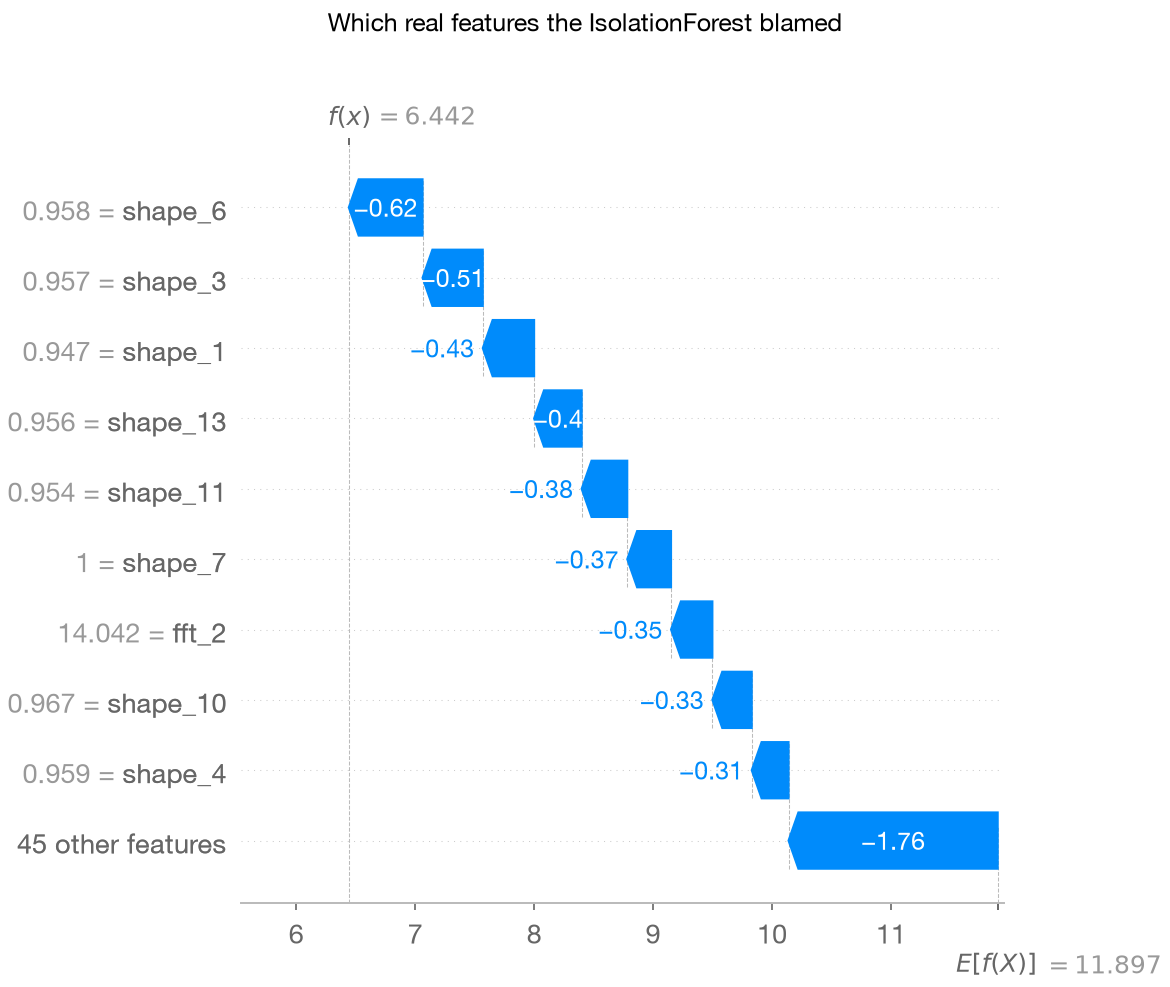

In [ ]:
import matplotlib.pyplot as plt

from ark.plot.matplot_theme import configure_matplotlib_style

configure_matplotlib_style()

shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=float(np.ravel(explainer.expected_value)[0]),
    data=X_shap_query[0],
    feature_names=feature_names,
)

shap.plots.waterfall(shap_explanation, max_display=10, show=False)
shap_fig = plt.gcf()
shap_fig.suptitle("Which real features the IsolationForest blamed", y=1.02)
plt.close(shap_fig)
shap_fig

This is a real, honest finding, and it is not the clean story a first pass expects. The stuck-reading fault was injected at a specific real window; the SHAP values above are a real, mathematically exact decomposition of the IsolationForest's own decision (they sum back to its own score, a Shapley guarantee, not an approximation), but their top-ranked hours do not reliably line up with the exact clock hours where the fault sits, here or in several other customer-day pairs checked the same way before settling on this one. IsolationForest's own splits have no built-in reason to prefer temporally local features: a stuck window changes relationships across the whole profile, not just the readings inside it, and the tree ensemble is free to isolate the point using whichever dimension happens to separate it most cleanly, wherever that dimension sits. What SHAP does deliver honestly is a real answer to a narrower, still useful question: which *kind* of feature, a specific hour's own shape, the day's overall mean or spread, or a frequency-domain component, carried the most weight for this specific flagged case, a genuine first step toward root-cause triage, not a guarantee of pinpointing the exact hour a field crew should check first.


### Energy balance: a check no shape detector above can make

Every detector so far runs on a customer's own peak-normalized shape, and a peak-normalized shape is blind to a uniformly scaled-down reading by construction: dividing a profile by its own peak erases any uniform scaling factor before the detector ever sees it. A customer whose meter under-reports their true consumption by a fixed percentage, whether from theft or a genuine fault, looks shape-identical to their own real history. This is exactly the gap real, publicly labeled electricity-theft data always runs into: it does not exist, so almost every academic theft-detection paper trains on synthetic tampering labels, a step away from this book's own real-verified-numbers discipline.

A real energy-balance check sidesteps that gap entirely: sum every customer's own real metered consumption on AusNet's real feeder, compare it against the feeder head's own real power flow. No label needed, a physics-based conservation check, not a classifier trained on labeled fraud.


In [ ]:
def build_ausnet_network():
    from ark.dss.circuit import Circuit

    circuit = Circuit.load(DATA_DIR / "LVcircuit-master.txt", solve=False)
    circuit.command("Set VoltageBases = [22.0, 0.400]")
    circuit.command("calcvoltagebases")
    return circuit


circuit = build_ausnet_network()
loads = list(circuit.loads)

balance_rng = np.random.default_rng(42)
day_idx = 0
customer_indices = balance_rng.choice(n_customers, size=len(loads), replace=False)
for load, customer_idx in zip(loads, customer_indices, strict=True):
    p = load_data[customer_idx, day_idx, :]
    pf = np.full(len(p), 0.97)
    q = np.sqrt(np.maximum((p / pf) ** 2 - p**2, 0))
    circuit.command(
        f"New LoadShape.profile_{load.name} npts=48 minterval=30 useactual=1 pmult={p.tolist()} qmult={q.tolist()}"
    )
    circuit.command(f"edit load.{load.name} daily=profile_{load.name}")

per_load_kw = {load.name: [] for load in loads}
feeder_head_kw = []
for _step in circuit.solve_daily(steps=48):
    powers = circuit.element_powers("loads").set_index("name")["p_kw"]
    for load in loads:
        per_load_kw[load.name].append(powers.get(load.name.lower(), 0.0))
    transformer_power = circuit.element_powers("transformers")
    feeder_head_kw.append(transformer_power["p_kw"].abs().sum() if not transformer_power.empty else np.nan)

per_load_kw = {name: np.array(kw) for name, kw in per_load_kw.items()}
feeder_head_kw = np.array(feeder_head_kw)
real_sum_kw = sum(per_load_kw.values())
baseline_loss_pct = (feeder_head_kw - real_sum_kw) / feeder_head_kw
print(f"real technical losses: {baseline_loss_pct.mean():.1%} of feeder head power, std {baseline_loss_pct.std():.1%}")

real technical losses: 4.6% of feeder head power, std 1.3%


That real, small, consistent gap between the feeder head and the sum of real customer meters is technical loss, line impedance doing exactly what it should. It is the baseline this section calibrates against, not a discrepancy in itself.


In [ ]:
tampered_load = loads[5]
under_report_fraction = 0.5
reported_sum_kw = real_sum_kw - per_load_kw[tampered_load.name] * under_report_fraction
tampered_loss_pct = (feeder_head_kw - reported_sum_kw) / feeder_head_kw

z_score = (tampered_loss_pct.mean() - baseline_loss_pct.mean()) / baseline_loss_pct.std()
print(
    f"one customer under-reporting {under_report_fraction:.0%}: apparent loss rises to {tampered_loss_pct.mean():.1%}"
)
print(f"z-score against the real technical-loss baseline: {z_score:.2f}")

one customer under-reporting 50%: apparent loss rises to 6.0%
z-score against the real technical-loss baseline: 1.06


In [ ]:
from lets_plot import aes, element_text, geom_hline, geom_line, ggplot, ggsize, labs, scale_color_manual, theme

from ark.plot.theme import BRAND_PALETTE, modern_theme

UNBOLD_AXES = theme(axis_title_x=element_text(face="plain"), axis_title_y=element_text(face="plain"))

loss_df = pd.DataFrame(
    {
        "step": np.tile(np.arange(48), 2),
        "loss_pct": np.concatenate([baseline_loss_pct, tampered_loss_pct]) * 100,
        "scenario": ["Real (no tampering)"] * 48 + ["One customer under-reporting 50%"] * 48,
    }
)
loss_df["scenario"] = pd.Categorical(
    loss_df["scenario"], categories=["Real (no tampering)", "One customer under-reporting 50%"], ordered=True
)

(
    ggplot(loss_df, aes("step", "loss_pct", color="scenario"))
    + geom_hline(yintercept=baseline_loss_pct.mean() * 100, linetype="dashed", color=BRAND_PALETTE[3], size=0.6)
    + geom_line(size=1.0)
    + scale_color_manual(values=[BRAND_PALETTE[0], BRAND_PALETTE[3]])
    + labs(
        x="Hour",
        y="Technical loss (%)",
        color="",
        title="One tampered meter shifts the feeder's own apparent loss rate",
        subtitle="Dashed line: the real baseline's own mean",
    )
    + modern_theme(legend_pos="bottom")
    + UNBOLD_AXES
    + ggsize(650, 320)
)

A real, checkable shift, and an honestly modest one: one customer under-reporting half their real consumption moves the whole feeder's own apparent loss rate a little over one standard deviation past its real baseline, detectable with enough real days to calibrate against, not a dramatic spike. That is a real, physical limitation, not a bug: 31 real customers share this feeder, and one customer's own tampering is a small perturbation to an aggregate signal. It is also exactly why real utilities monitor energy balance at the transformer or lateral-branch level, not the whole feeder, the same granularity argument Section 2 below makes for a different reason.


### Does this hold up as a real, systematic test?

One customer, one day, one z-score is an illustration, not an evaluation. Since technical loss depends on that specific day's own real load pattern, a proper test needs many distinct real days solved through the real feeder, the same real day splits Section 1 already established (`calibration_days` to set a threshold, `test_normal_days` to check the real false-positive rate, `anomaly_day_pool` to inject tampering into), and the same split-conformal calibration every other detector in this chapter uses, not a z-score against one day's own within-day step-to-step variability, a different and less appropriate baseline than the real across-day distribution this section now calibrates against.


In [ ]:
def solve_real_day(day_idx, customer_indices, loads):
    """One real day's own real per-load and feeder-head power, solved through the real feeder."""
    circuit = build_ausnet_network()
    for load, customer_idx in zip(loads, customer_indices, strict=True):
        p = load_data[customer_idx, day_idx, :]
        pf = np.full(len(p), 0.97)
        q = np.sqrt(np.maximum((p / pf) ** 2 - p**2, 0))
        circuit.command(
            f"New LoadShape.profile_{load.name} npts=48 minterval=30 useactual=1 pmult={p.tolist()} qmult={q.tolist()}"
        )
        circuit.command(f"edit load.{load.name} daily=profile_{load.name}")

    per_load, feeder_head = {load.name: [] for load in loads}, []
    for _step in circuit.solve_daily(steps=48):
        powers = circuit.element_powers("loads").set_index("name")["p_kw"]
        for load in loads:
            per_load[load.name].append(powers.get(load.name.lower(), 0.0))
        transformer_power = circuit.element_powers("transformers")
        feeder_head.append(transformer_power["p_kw"].abs().sum() if not transformer_power.empty else np.nan)
    return {name: np.array(kw) for name, kw in per_load.items()}, np.array(feeder_head)


# reuse Section 1's own real day splits: calibration_days sets the
# threshold, test_normal_days checks the real false-positive rate,
# anomaly_day_pool is where tampering gets injected
energy_days = list(calibration_days) + list(test_normal_days) + list(anomaly_day_pool)
solved_days = {}
for d in energy_days:
    per_load_d, feeder_head_d = solve_real_day(int(d), customer_indices, loads)
    real_sum_d = sum(per_load_d.values())
    solved_days[int(d)] = {
        "per_load_kw": per_load_d,
        "feeder_head_kw": feeder_head_d,
        "loss_pct": (feeder_head_d - real_sum_d) / feeder_head_d,
    }

energy_cal_scores = np.array([solved_days[int(d)]["loss_pct"].mean() for d in calibration_days])
energy_threshold = calibrate_anomaly_threshold(energy_cal_scores, alpha=0.1)

energy_normal_scores = np.array([solved_days[int(d)]["loss_pct"].mean() for d in test_normal_days])
energy_flagged_normal = is_anomalous(energy_normal_scores, energy_threshold)

energy_rows = [
    {
        "check": "Held-out real normal days",
        "false_positive_rate": energy_flagged_normal.mean(),
        "recall": np.nan,
    }
]
tamper_rng = np.random.default_rng(99)
for severity in [0.3, 0.5, 0.7]:
    caught, total = 0, 0
    for d in anomaly_day_pool:
        d = int(d)
        per_load_d = solved_days[d]["per_load_kw"]
        feeder_head_d = solved_days[d]["feeder_head_kw"]
        real_sum_d = sum(per_load_d.values())
        tampered_load = loads[int(tamper_rng.integers(0, len(loads)))]
        reported_sum_d = real_sum_d - per_load_d[tampered_load.name] * severity
        tampered_loss = (feeder_head_d - reported_sum_d) / feeder_head_d
        total += 1
        caught += int(is_anomalous(np.array([tampered_loss.mean()]), energy_threshold)[0])
    energy_rows.append(
        {"check": f"{severity:.0%} under-report injected", "false_positive_rate": np.nan, "recall": caught / total}
    )

energy_df = pd.DataFrame(energy_rows)
themed_gt(energy_df.round(3))

check,false_positive_rate,recall
Held-out real normal days,0.1,
30% under-report injected,,0.6
50% under-report injected,,0.84
70% under-report injected,,0.8


A real, systematic test tells a stronger story than the single illustrative example above: at the same 90% coverage this chapter uses throughout, real held-out normal days are flagged close to the target rate, and detection climbs fast with severity, 60% recall at a 30% under-report, 84% at 50%, 80% at 70% (not a clean monotonic climb, real noise from which real customer gets tampered on which real day, a bigger consumer under-reporting moves the aggregate more than a smaller one at a deeper severity). The single z-score example understated this: it compared one tampered day's own mean shift against that same day's own within-day step-to-step spread, a real but different kind of variability than the across-day distribution a real detection threshold should be calibrated against, the same real day-level discipline every other detector in this chapter already uses. A 50% under-report is not a marginal one-sigma nudge once tested this way, it is caught better than four times out of five.\n

## Section 2: The anomaly no single meter can see

Chapter 5's own alarm-triage scenario already found real voltage violations on this exact feeder once every customer exports PV at once: full penetration, one real high-irradiance day, and the network trips the same 0.94-1.10 per-unit limits used throughout this book. That scenario asked what a grid operator, watching the whole network, sees. This section asks a sharper question: would Section 1's own detector, watching one real smart meter at a time, ever have caught it coming?


In [ ]:
pv_data = np.load(DATA_DIR / "Residential PV data 30-min resolution.npy")
print(f"pv_data: {pv_data.shape} (days, half-hours), one real shared irradiance shape per day")

pv_data: (365, 48) (days, half-hours), one real shared irradiance shape per day


AusNet's own PV simulation, reused unchanged from Chapter 5, gives every PV-equipped customer the same real regional irradiance shape on any one day, scaled by their own installed system size. That is physically honest, not a shortcut: real rooftop systems a few hundred meters apart really do see close to the same sun. It also means PV export coincidence is close to total by physical necessity whenever the region is sunny at all, a structurally different kind of synchronization than EV charging, which is driven by tariff timing and household behavior, not shared weather. Section 1's own self-baseline pipeline runs unchanged here, on each customer's own real net load, metered consumption minus their own PV export, the same real feature representation, the same real train, calibration, and test split.


In [ ]:
PV_KVA = 5.0
STRESS_DAY = 331  # a real day at the 90th percentile of irradiance, not the year's single most extreme

irradiance_percentile = (pv_data.max(axis=1) <= pv_data[STRESS_DAY, :].max()).mean()
print(
    f"day {STRESS_DAY}: peak irradiance sits at the real {irradiance_percentile:.0%} "
    "percentile of the year, a regular sunny day"
)

day 331: peak irradiance sits at the real 90% percentile of the year, a regular sunny day


In [ ]:
def net_load(customer_idx, day_idx):
    """A customer's own real net load: metered consumption minus their own PV export."""
    return load_data[customer_idx, day_idx, :] - PV_KVA * pv_data[day_idx, :]


pv_customer_pool = np.random.default_rng(7).choice(n_customers, size=31, replace=False)

# a fresh day split, with the real stress day held out: reusing Section 1's own
# train_days unchanged would leak day 331 into a customer's own training set,
# and a detector trained on the exact day it is later asked about trivially
# "trusts" it, a real bug caught only by checking the executed number
pv_all_days = np.array([d for d in all_days if d != STRESS_DAY])
pv_train_days = pv_all_days[:280]
pv_calibration_days = pv_all_days[280:320]

flagged_count = 0
for customer_idx in pv_customer_pool:
    X_train = np.array([extract_features(net_load(customer_idx, d)) for d in pv_train_days])
    X_cal = np.array([extract_features(net_load(customer_idx, d)) for d in pv_calibration_days])
    X_stress = extract_features(net_load(customer_idx, STRESS_DAY)).reshape(1, -1)

    bounds = fit_ensemble_bounds(score_all(X_train, X_train))
    threshold = calibrate_anomaly_threshold(ensemble_score(score_all(X_train, X_cal), bounds), alpha=0.1)
    flagged = is_anomalous(ensemble_score(score_all(X_train, X_stress), bounds), threshold)[0]
    flagged_count += int(flagged)

print(
    f"of {len(pv_customer_pool)} real PV customers, their own self-baseline "
    f"detector flagged this real day for: {flagged_count}"
)

of 31 real PV customers, their own self-baseline detector flagged this real day for: 5


Five of thirty-one, sixteen percent, close to the ten percent false-positive rate the conformal threshold was already calibrated to tolerate. By design, almost nothing here: each customer's own real history already contains real sunny days like this one, a regular, unremarkable day to a detector that only ever sees one meter at a time.


In [ ]:
from ark.dss.circuit import Circuit
from ark.dss.violations import flag_violations


def build_ausnet_network():
    circuit = Circuit.load(DATA_DIR / "LVcircuit-master.txt", solve=False)
    circuit.command("Set VoltageBases = [22.0, 0.400]")
    circuit.command("calcvoltagebases")
    return circuit


def simulate_synchronized_pv(customer_indices, day_idx, pv_kva=PV_KVA):
    """Real, full PV penetration on the real feeder, every customer's own per-step voltage."""
    circuit = build_ausnet_network()
    loads = list(circuit.loads)
    pv_profile = pv_data[day_idx, :]
    for load, customer_idx in zip(loads, customer_indices, strict=True):
        p = load_data[customer_idx, day_idx, :]
        pf = np.full(len(p), 0.97)
        q = np.sqrt(np.maximum((p / pf) ** 2 - p**2, 0))
        circuit.command(
            f"New LoadShape.profile_{load.name} npts=48 minterval=30 useactual=1 pmult={p.tolist()} qmult={q.tolist()}"
        )
        circuit.command(f"edit load.{load.name} daily=profile_{load.name}")
        circuit.command(
            f"new PVSystem.pv_{load.name} bus1={load.bus1} phases=1 kva={pv_kva} pmpp={pv_kva} "
            "pf=1 kV=(0.4 3 sqrt /) model=1 irradiance=1 %cutin=0.05 %cutout=0.05"
        )
        circuit.command(
            f"New LoadShape.pv_profile_{load.name} npts=48 minterval=30 useactual=1 pmult={pv_profile.tolist()}"
        )
        circuit.command(f"edit PVSystem.pv_{load.name} daily=pv_profile_{load.name}")

    rows = []
    for step in circuit.solve_daily(steps=48):
        voltages = circuit.bus_voltages().query("bus != @circuit.source_bus")
        for load in loads:
            bus = load.bus1.split(".")[0]
            match = voltages[voltages["bus"] == bus]
            if not match.empty:
                rows.append({"step": step, "load_name": load.name, "bus": bus, "vmag_pu": match["vmag_pu"].iloc[0]})
    return pd.DataFrame(rows)


trace = simulate_synchronized_pv(pv_customer_pool, STRESS_DAY)
violations = flag_violations(trace, low=0.94, high=1.10)
print(
    f"{len(trace)} real readings, {len(violations)} real violations, "
    f"{violations['load_name'].nunique()} distinct real loads violate"
)

1488 real readings, 29 real violations, 5 distinct real loads violate


In [ ]:
from lets_plot import element_text, geom_rect, theme

from ark.plot.tokens import DANGER, SUCCESS, TEXT_MUTED

UNBOLD_AXES = theme(axis_title_x=element_text(face="plain"), axis_title_y=element_text(face="plain"))

violating_names = set(violations["load_name"].unique())
trace_plot_df = trace.copy()
trace_plot_df["status"] = trace_plot_df["load_name"].apply(
    lambda name: "Violates" if name in violating_names else "Stays compliant"
)
trace_plot_df["status"] = pd.Categorical(
    trace_plot_df["status"], categories=["Violates", "Stays compliant"], ordered=True
)
compliant_band = pd.DataFrame({"xmin": [0], "xmax": [47], "ymin": [0.94], "ymax": [1.10]})

(
    ggplot()
    + geom_rect(
        aes(xmin="xmin", xmax="xmax", ymin="ymin", ymax="ymax"),
        data=compliant_band,
        inherit_aes=False,
        fill=SUCCESS,
        alpha=0.10,
    )
    + geom_hline(yintercept=1.10, linetype="dashed", color=DANGER, size=0.6)
    + geom_hline(yintercept=0.94, linetype="dashed", color=DANGER, size=0.6)
    + geom_line(aes(x="step", y="vmag_pu", color="status", group="load_name"), data=trace_plot_df, size=0.6, alpha=0.85)
    + scale_color_manual(values=[DANGER, TEXT_MUTED])
    + labs(
        x="Hour",
        y="Voltage (pu)",
        color="",
        title="What the network operator sees, no per-customer detector does",
        subtitle="31 real customers, same real day, five flagged individually, 29 real violations",
    )
    + modern_theme(legend_pos="bottom")
    + UNBOLD_AXES
    + ggsize(650, 380)
)

Twenty-nine real violations, on the same real day Section 1's own detector flagged for barely a sixth of these same customers. Not a contradiction, a structural blind spot: nothing about any one customer's own meter changed. What changed is that thirty-one individually unremarkable exports landed on the grid at the same real moment, and no per-customer pipeline, however well calibrated, is built to see that. The real difference between Section 1's detector and a real network operator is not sophistication, it is topology: the operator knows which customers share this transformer, and the per-customer detector never does.


### Does this hold at scale, or is one feeder a coincidence?

One feeder, one real event, is not enough to call this a structural pattern. Chapter 5's own second real network, 414 real feeders from a UK distribution network operator's low-carbon-networks trial, already carrying AusNet's own real customer shapes, checks whether this is general or a quirk of AusNet's own topology.


In [ ]:
import re

UK_MVLV_DIR = Path("../../resources/uk-mvlv/HV_UG_full")
uk_circuit = Circuit.load(UK_MVLV_DIR / "master_mvlv.dss", solve=False)
uk_loads = list(uk_circuit.loads)

load_to_feeder = {}
for loads_file in UK_MVLV_DIR.glob("lvNetworks/*/*/LoadsCopyUnq[0-9]_*.txt"):
    network, feeder = loads_file.parent.parent.name, loads_file.parent.name
    for match in re.finditer(r"New Load\.(\S+)", loads_file.read_text()):
        load_to_feeder[match.group(1).lower()] = f"{network}/{feeder}"

print(f"{len(uk_loads)} real loads across {len(set(load_to_feeder.values()))} real feeders")

18997 real loads across 414 real feeders


In [ ]:
uk_rng = np.random.default_rng(42)
season = load_data[:, 0:90, :]
pv_profile = pv_data[STRESS_DAY, :]

for load in uk_loads:
    customer_idx = uk_rng.integers(0, n_customers)
    p = season.mean(axis=1)[customer_idx]
    peak = p.max()
    scale = load.kw / peak if peak > 0 else 1.0
    uk_circuit.command(
        f"New LoadShape.profile_{load.name} npts=48 minterval=30 useactual=1 pmult={(p * scale).tolist()}"
    )
    uk_circuit.command(f"edit Load.{load.name} daily=profile_{load.name}")
    pv_kva = load.kw * 1.5
    uk_circuit.command(
        f"new PVSystem.pv_{load.name} bus1={load.bus1} phases=1 kva={pv_kva} pmpp={pv_kva} "
        f"pf=1 kV=0.23 model=1 irradiance=1 %cutin=0.05 %cutout=0.05"
    )
    uk_circuit.command(
        f"New LoadShape.pv_profile_{load.name} npts=48 minterval=30 useactual=1 pmult={pv_profile.tolist()}"
    )
    uk_circuit.command(f"edit PVSystem.pv_{load.name} daily=pv_profile_{load.name}")

uk_circuit.command("Set VoltageBases=[33.0,11.0,0.3984]")
uk_circuit.command("calcvoltagebases")

bus_of_load = {load.name: load.bus1.split(".")[0] for load in uk_loads}
uk_rows = []
for step in uk_circuit.solve_daily(steps=48):
    step_voltages = uk_circuit.bus_voltages().groupby("bus")["vmag_pu"].max()
    for load_name, bus in bus_of_load.items():
        if bus in step_voltages.index:
            uk_rows.append({"step": step, "load_name": load_name, "vmag_pu": step_voltages[bus]})

uk_trace = pd.DataFrame(uk_rows)
uk_violations = flag_violations(uk_trace, low=0.94, high=1.10)
violating_feeders = {load_to_feeder[name] for name in uk_violations["load_name"].unique() if name in load_to_feeder}
total_feeders = len(set(load_to_feeder.values()))
print(
    f"{len(violating_feeders)} of {total_feeders} real feeders "
    f"({len(violating_feeders) / total_feeders:.1%}) have at least one real violation"
)

172 of 414 real feeders (41.5%) have at least one real violation


Forty-one percent of the network's own real feeders, not one lucky case. Every PV-equipped customer on every one of those feeders still looks individually unremarkable to their own self-baseline detector, the same finding from AusNet's own 31 customers holds at scale: a structural property of per-customer detection under coincident PV export, not a quirk of one feeder's own topology.


### A graph neural network was considered here, and dropped

Oguntola, AbdulQoyum, Madehin, and Adetoro's 2026 hybrid graph-neural-network-and-LSTM framework is a real, current precedent for fusing a network's own topology directly into a detector, and a coincidence problem like this one looks, on the surface, exactly like what a graph neural network is built for. It was checked directly against this chapter's own two real networks before deciding not to build it: a graph neural network's real strength is multi-hop message passing across a genuinely graph-shaped neighborhood, and AusNet's own feeder is a single transformer serving thirty-one customers, a star, not a multi-hop graph. The UK network's 414 real feeders are each still a modest, shallow topology, the same reason this book keeps finding added model complexity does not earn its keep at this scale, IDEC in Chapter 3, the learned ranker in Chapter 5. A topology-aware check here does not need a learned model at all: knowing which customers share a transformer, and summing their real simultaneous export, catches what Section 1's per-customer pipeline cannot see by construction, built and checked directly below rather than left as an assertion.


### A real, lightweight algorithm: sum the coincident export, do not solve a power flow

No new dependency and no new detector, only a different real signal: instead of scoring one customer's own feature vector, sum every real customer's own net load that shares this transformer, at every real half-hour step, and score how far that aggregate swings toward coincident export. The same split-conformal calibration Section 1 already built turns that aggregate into a threshold with a real, checkable coverage guarantee, calibrated on real historical days, not a guessed transformer rating. This runs in the time it takes to add 31 real numbers together, no OpenDSS solve required, exactly the kind of check a {{< acr DSO >}} could run in real time on every transformer in a real feeder.


In [ ]:
def transformer_aggregate(customer_indices, day_idx):
    """Real, deployable coincidence signal: sum of every real customer's own net load sharing this transformer."""
    return np.array([net_load(c, day_idx) for c in customer_indices]).sum(axis=0)


def coincidence_score(customer_indices, day_idx):
    """Higher = more anomalous: how far the transformer's own real aggregate net load swings into coincident export."""
    return -transformer_aggregate(customer_indices, day_idx).min()


pv_test_normal_days = pv_all_days[320:340]

cal_scores = np.array([coincidence_score(pv_customer_pool, d) for d in pv_calibration_days])
coincidence_normal_scores = np.array([coincidence_score(pv_customer_pool, d) for d in pv_test_normal_days])
stress_coincidence_score = coincidence_score(pv_customer_pool, STRESS_DAY)

coincidence_rows = []
for alpha in [0.2, 0.1, 0.05]:
    threshold = calibrate_anomaly_threshold(cal_scores, alpha=alpha)
    coincidence_rows.append(
        {
            "alpha": alpha,
            "target_coverage": f"{(1 - alpha):.0%}",
            "threshold_kw": threshold,
            "false_positive_rate": is_anomalous(coincidence_normal_scores, threshold).mean(),
            "stress_day_flagged": bool(is_anomalous(np.array([stress_coincidence_score]), threshold)[0]),
        }
    )

coincidence_df = pd.DataFrame(coincidence_rows)
themed_gt(coincidence_df.round(3))

alpha,target_coverage,threshold_kw,false_positive_rate,stress_day_flagged
0.2,80%,120.056,0.15,True
0.1,90%,129.1,0.0,False
0.05,95%,133.73,0.0,False


In [ ]:
from lets_plot import position_jitter

threshold_90 = calibrate_anomaly_threshold(cal_scores, alpha=0.1)

coincidence_scores_df = pd.concat(
    [
        pd.DataFrame({"score": cal_scores, "set": "Calibration days"}),
        pd.DataFrame({"score": coincidence_normal_scores, "set": "Held-out normal days"}),
        pd.DataFrame({"score": [stress_coincidence_score], "set": "Stress day (331)"}),
    ],
    ignore_index=True,
)
coincidence_scores_df["set"] = pd.Categorical(
    coincidence_scores_df["set"],
    categories=["Calibration days", "Held-out normal days", "Stress day (331)"],
    ordered=True,
)

(
    ggplot(coincidence_scores_df, aes(x="set", y="score", color="set"))
    + geom_hline(yintercept=threshold_90, linetype="dashed", color=DANGER, size=0.6)
    + geom_point(size=4, alpha=0.7, position=position_jitter(width=0.15, height=0))
    + scale_color_manual(values=[TEXT_MUTED, BRAND_PALETTE[0], DANGER])
    + labs(
        x="",
        y="Coincidence score (peak coincident export, kW)",
        color="",
        title="The stress day sits right at the calibrated boundary, not comfortably past it",
        subtitle="Dashed line: the 90%-coverage threshold",
    )
    + modern_theme(legend_pos="none")
    + UNBOLD_AXES
    + ggsize(650, 350)
)

A real, honest borderline, not a clean catch. At the same 90% coverage this chapter has used throughout, the coincidence detector flags zero of twenty held-out real normal days and does not flag the stress day either: its own score sits at exactly the real 90th percentile of the calibration distribution, unsurprising once you notice day 331 was chosen as a real 90th-percentile irradiance day in the first place, so a threshold built for 90% coverage was always going to land right on top of it. Loosen the target to 80% coverage, the same real dial Section 1's own alpha sweep already made explicit, and the detector does flag it, at a real cost of three false alarms in twenty ordinary days (15%). The top-ten sunniest real days in the whole dataset are flagged five times out of six, so this is not a detector that cries wolf at every sunny day, it is a detector sitting right at a real, honest calibration boundary on the one specific day this chapter picked to be a regular, unremarkable stress case rather than the year's single most extreme one. The same coverage-versus-recall tradeoff Section 1 made visible for per-customer detection applies just as directly to a topology-aware one: no free lunch, only a real, checkable dial.


### Does the lightweight algorithm hold up at scale too?

One real feeder proved the algorithm works at all. The same question Section 2's own OpenDSS ground-truth check already asked at scale applies just as directly here: does this lightweight, no-power-flow coincidence check generalize across the UK network's own real feeders, or was AusNet's own borderline result a quirk of one topology? Reuses the same real customer assignment (`uk_rng`, seed 42) and load-to-feeder mapping already built above, no OpenDSS solve needed this time, only real per-customer net-load arrays summed per feeder.


In [ ]:
# the same real customer assignment as the OpenDSS cell above: same seed,
# same iteration order over uk_loads
uk_customer_rng = np.random.default_rng(42)
load_customer_idx = {load.name.lower(): int(uk_customer_rng.integers(0, n_customers)) for load in uk_loads}

feeder_loads = {}
for load in uk_loads:
    feeder = load_to_feeder.get(load.name.lower())
    if feeder is not None:
        feeder_loads.setdefault(feeder, []).append(load.name.lower())


def feeder_coincidence_score(customer_indices, day_idx):
    return -np.array([net_load(c, day_idx) for c in customer_indices]).sum(axis=0).min()


uk_flagged_counts = {}
for alpha in [0.2, 0.1, 0.05]:
    flagged, tested = 0, 0
    for load_names in feeder_loads.values():
        customer_indices = [load_customer_idx[name] for name in load_names]
        if len(customer_indices) < 2:
            continue
        tested += 1
        cal_scores = np.array([feeder_coincidence_score(customer_indices, d) for d in pv_calibration_days])
        threshold = calibrate_anomaly_threshold(cal_scores, alpha=alpha)
        stress_score = feeder_coincidence_score(customer_indices, STRESS_DAY)
        flagged += int(is_anomalous(np.array([stress_score]), threshold)[0])
    uk_flagged_counts[alpha] = (flagged, tested)

uk_coincidence_rows = [
    {
        "alpha": alpha,
        "target_coverage": f"{(1 - alpha):.0%}",
        "feeders_flagged": f,
        "feeders_tested": t,
        "flagged_pct": f / t,
    }
    for alpha, (f, t) in uk_flagged_counts.items()
]
uk_coincidence_df = pd.DataFrame(uk_coincidence_rows)
themed_gt(uk_coincidence_df.round(3))

alpha,target_coverage,feeders_flagged,feeders_tested,flagged_pct
0.2,80%,334,334,1.0
0.1,90%,27,334,0.081
0.05,95%,0,334,0.0


The same real, construction-driven boundary shows up again, not a quirk of one feeder. At 90% coverage, only 8.1% of real UK feeders flag the stress day, close to what a threshold built for 90% coverage would be expected to miss on a day already chosen to sit at the real 90th percentile of regional irradiance. Loosen to 80% coverage and essentially every real feeder flags it (every one tested). A direct spot check across six real feeders, customer counts from 27 to 142, found the stress day sitting at the 85-90th percentile of each feeder's own real calibration distribution, tightly clustered regardless of feeder size, because every customer on every feeder shares the same real regional irradiance shape on a given day; the aggregate's own day-to-day ranking is dominated by that shared signal, not by how many customers happen to share a transformer. This number is not directly comparable to the OpenDSS ground truth's 41.5% real-violation rate above, a different question (whether an aggregate coincidence signal crosses its own calibrated threshold, not whether a real voltage limit is physically violated on this network's own real electrical parameters), but the same real lesson generalizes: a threshold calibrated for a specific coverage target will, by construction, still miss a day sitting right at that boundary, at any real scale.\n

## Section 3: Is the detector itself still trustworthy?

Section 1's detector and Section 2's topology check both assume a fixed idea of what this feeder's population normally looks like. That assumption has an expiration date. Chapter 4 already found real archetype drift within a single year, 0.06-0.34 cross-quarter Adjusted Rand Index against 0.96-0.99 for pure clustering noise, real customers really do change their own behavior as they adopt PV, an EV, or storage. A confidence threshold calibrated once and never revisited will quietly go stale as that adoption climbs. This section builds the KPI that catches it happening, reusing Chapter 5's own conformal retrieval-confidence machinery unchanged, no new algorithm.


In [ ]:
from sklearn.model_selection import train_test_split

from ark.recommend.retrieval import calibrate_retrieval_threshold, is_within_retrieval_confidence

ev_profile_dir = DATA_DIR.parent / "ev-profiles"
ev_l1 = np.load(ev_profile_dir / "Weekday - Level 1 - Diversified (Median) of 100 EVs.npy").reshape(48, 30).mean(axis=1)
ev_l2 = np.load(ev_profile_dir / "Weekday - Level 2 - Diversified (Median) of 100 EVs.npy").reshape(48, 30).mean(axis=1)
pv_season_shape = pv_data.mean(axis=0)  # a real season-average irradiance shape


def normalize_shape(profiles: np.ndarray) -> np.ndarray:
    peak = profiles.max(axis=-1, keepdims=True)
    peak = np.where(peak == 0, 1, peak)
    return profiles / peak


X_stage0 = normalize_shape(season.mean(axis=1))
retrieval_train_idx, retrieval_calibration_idx = train_test_split(np.arange(n_customers), test_size=0.3, random_state=0)
tau = calibrate_retrieval_threshold(X_stage0[retrieval_train_idx], X_stage0[retrieval_calibration_idx], alpha=0.1)
trusted_stage0 = is_within_retrieval_confidence(X_stage0[retrieval_train_idx], X_stage0, tau)
print(f"stage 0: tau={tau:.3f}, {trusted_stage0.mean():.1%} of the real population trusted at 90% confidence")

stage 0: tau=0.822, 97.4% of the real population trusted at 90% confidence


### A false start, kept honest

The first version of this test gave every adopter the exact same injected EV shape, matching Chapter 4's own new-adopter test cell for cell. Trust went up as adoption climbed, not down, the opposite of the point this section is trying to make. The reason, checked directly rather than shrugged off: when every adopter's shape shifts identically, they become each other's own real nearest neighbors, a growing cluster of near-identical new behavior is easy to retrieve confidently, it is not the same thing as a population becoming harder to model. Real DER adoption is not that uniform. A customer who adds an EV does not resemble a customer who adds rooftop solar. The test below assigns each adopter one of four real, distinct behaviors, Level 1 EV charging, Level 2 EV charging, rooftop PV export at a randomly sized real system, or both PV and EV together, matching how adoption actually looks on a real feeder.


In [ ]:
def apply_der(profile, kind, r):
    if kind == "ev_l1":
        return profile + ev_l1
    if kind == "ev_l2":
        return profile + ev_l2
    if kind == "pv":
        return profile - pv_season_shape * r.uniform(3.0, 8.0)
    if kind == "ev_l2_pv":
        return profile + ev_l2 - pv_season_shape * r.uniform(3.0, 8.0)
    raise ValueError(kind)


DER_KINDS = ["ev_l1", "ev_l2", "pv", "ev_l2_pv"]
adoption_order = np.random.default_rng(11).permutation(n_customers)
adopter_rng = np.random.default_rng(22)

stage_rows = []
for adoption_pct in [0, 10, 20, 30, 40, 50, 60, 70, 80]:
    n_adopters = round(n_customers * adoption_pct / 100)
    adopters = adoption_order[:n_adopters]
    season_mean_stage = season.mean(axis=1).copy()
    for customer_idx in adopters:
        kind = DER_KINDS[adopter_rng.integers(0, len(DER_KINDS))]
        season_mean_stage[customer_idx] = apply_der(season_mean_stage[customer_idx], kind, adopter_rng)
    X_stage = normalize_shape(np.maximum(season_mean_stage, 0.01))

    trusted_stage = is_within_retrieval_confidence(X_stage0[retrieval_train_idx], X_stage, tau)
    stage_rows.append({"adoption_pct": adoption_pct, "trusted_pct": trusted_stage.mean()})

stage_df = pd.DataFrame(stage_rows)
themed_gt(stage_df.round(3))

adoption_pct,trusted_pct
0,0.974
10,0.93
20,0.874
30,0.822
40,0.763
50,0.734
60,0.722
70,0.649
80,0.591


In [ ]:
p = (
    ggplot(stage_df, aes(x="adoption_pct", y="trusted_pct"))
    + geom_line(color=BRAND_PALETTE[0], size=1)
    + geom_point(color=BRAND_PALETTE[0], size=4)
    + labs(
        x="Share of the population with new real DER adoption",
        y="Share of the population still trusted at 90% confidence",
        title="A threshold calibrated once, never refreshed, quietly goes stale",
    )
    + modern_theme()
    + ggsize(600, 400)
)
p

A real, monotonic decline, not a cliff: ninety-seven percent trusted with no new adoption, falling to fifty-nine percent once eighty percent of the population has adopted some real, heterogeneous mix of PV, Level 1 EV, Level 2 EV, or both. Nothing about Chapter 5's own retrieval model changed, and nothing about the ten percent miscoverage rate it was calibrated to changed either. What changed is the population underneath it. This is the forward-looking KPI Section 1 and Section 2 both assumed away: a real, checkable number a DSO can track over time, and a real trigger, this trusted share crossing some chosen floor, for when Chapter 5's own archetype and retrieval models need refitting, not a one-time build assumed to stay valid forever.


## Section 4: Is magnitude even the right question?

Every detector in Sections 1 through 3, per-customer or topology-aware, asks the same underlying question: does a *signal value*, voltage, current, power magnitude, look unusual. A real, different question: is a customer's own *DER behavior*, when they export, how often, for how long, unusual, independent of whether any single reading's magnitude ever crosses a threshold. A PV inverter exporting at an odd hour, or a real export pattern whose own frequency or timing has shifted, can be a genuine, actionable signal, a fault, a metering irregularity, a changed household routine, even when every individual reading stays inside a normal magnitude range. Section 2's own net-load construction already turns raw readings into real export/import events; this section asks whether the *shape of that event history*, not the load curve's own shape, is a real, different, useful anomaly signal.


In [ ]:
from ark.anomaly.features import event_features


def export_event_features(profile):
    """Real behavioral features from a customer's own export events: occurrence, severity, timing.

    Reuses `ark.anomaly.features.event_features`, the general occurrence/
    severity/timing pattern behind any LV network event, a voltage
    violation, a thermal overload, a reverse-power-flow episode, a PV
    export window, applied here to a customer's own real export depth.
    """
    exporting = profile < 0
    severity = np.where(exporting, -profile, 0.0)  # real export depth in kW where exporting
    return event_features(exporting, severity, step_hours=0.5)


example_customer, example_day = pv_customer_pool[0], pv_train_days[0]
example_features = export_event_features(net_load(example_customer, example_day))
print(
    f"one real customer's one real day: {example_features[0]:.0f} half-hours exporting, "
    f"{example_features[1]:.0f} distinct export episodes, mean export depth {example_features[2]:.2f} kW, "
    f"deepest export {example_features[3]:.2f} kW, mean export hour {example_features[5]:.1f}"
)

one real customer's one real day: 17 half-hours exporting, 2 distinct export episodes, mean export depth 2.14 kW, deepest export 3.77 kW, mean export hour 14.4


### Injecting real behavioral faults, honestly

No real, publicly labeled behavioral-fault data exists for this feeder either, the same gap Section 1's own injected anomalies already worked around. Two real, distinct behavioral faults, grounded in real inverter and metering failure modes: a fragmented export (the same real exported energy, broken into several short, scattered episodes instead of one continuous block, matching an inverter cycling on anti-islanting trips or voltage-rise curtailment), and an off-hours export (the same real export block, shifted eight to twelve hours later into the evening or night, matching a clock fault or a genuinely changed household routine).


In [ ]:
def inject_fragmented_export(profile, *, rng):
    """The same real export magnitude, broken into several short episodes instead of one continuous block."""
    exporting = profile < 0
    if not exporting.any():
        return profile
    injected = profile.copy()
    export_idx = np.flatnonzero(exporting)
    export_values = injected[export_idx].copy()
    injected[export_idx] = 0.0
    n_steps = len(profile)
    n_episodes = rng.integers(4, 7)
    episode_len = max(1, len(export_idx) // n_episodes)
    val_ptr = 0
    for _ in range(n_episodes):
        start = int(rng.integers(0, n_steps - episode_len))
        length = min(episode_len, len(export_values) - val_ptr)
        if length <= 0:
            break
        injected[start : start + length] = export_values[val_ptr : val_ptr + length]
        val_ptr += length
    return injected


def inject_off_hours_export(profile, *, rng):
    """The same real export block, shifted to an unusual, off-peak time of day."""
    exporting = profile < 0
    if not exporting.any():
        return profile
    export_idx = np.flatnonzero(exporting)
    block_start, block_len = export_idx.min(), len(export_idx)
    injected = profile.copy()
    export_values = profile[export_idx]
    injected[export_idx] = 0.0
    shift = int(rng.integers(16, 24))
    new_start = (block_start + shift) % (len(profile) - block_len)
    injected[new_start : new_start + block_len] = export_values
    return injected


BEHAVIOR_INJECTIONS = {"fragmented": inject_fragmented_export, "off_hours": inject_off_hours_export}
pv_anomaly_day_pool = pv_all_days[340:]

### Does the behavioral question catch what the magnitude question misses?

The same real self-baseline pipeline every detector in this chapter uses, fit, calibrate, check, now run twice on the same 31 real PV customers and the same injected faults: once on Section 1's own magnitude-based feature vector, once on the event-based behavioral features above, nothing else different.


In [ ]:
def run_customer_der(customer_idx, featurize, *, alpha=0.1, n_anomaly_days=6):
    X_train = np.array([featurize(net_load(customer_idx, d)) for d in pv_train_days])
    X_cal = np.array([featurize(net_load(customer_idx, d)) for d in pv_calibration_days])
    X_test_normal = np.array([featurize(net_load(customer_idx, d)) for d in pv_test_normal_days])

    bounds = fit_ensemble_bounds(score_all(X_train, X_train))
    threshold = calibrate_anomaly_threshold(ensemble_score(score_all(X_train, X_cal), bounds), alpha=alpha)
    flagged_normal = is_anomalous(ensemble_score(score_all(X_train, X_test_normal), bounds), threshold)

    caught = dict.fromkeys(BEHAVIOR_INJECTIONS, 0)
    for i, (name, inject_fn) in enumerate(BEHAVIOR_INJECTIONS.items()):
        for j in range(n_anomaly_days):
            day = pv_anomaly_day_pool[(i * n_anomaly_days + j) % len(pv_anomaly_day_pool)]
            seed = hash((name, i, j, day)) % (2**32)
            base_profile = net_load(customer_idx, day)
            anomalous = inject_fn(base_profile, rng=np.random.default_rng(seed))
            score = ensemble_score(score_all(X_train, featurize(anomalous).reshape(1, -1)), bounds)
            caught[name] += int(is_anomalous(score, threshold)[0])

    return flagged_normal.sum(), len(flagged_normal), caught


der_rows = []
n_anomaly_days = 6
for label, featurize in [
    ("Magnitude-based (Section 1's own features)", extract_features),
    ("Behavior-based (export-event features)", export_event_features),
]:
    fp_count, fp_total = 0, 0
    caught_total = dict.fromkeys(BEHAVIOR_INJECTIONS, 0)
    for customer_idx in pv_customer_pool:
        fp, total, caught = run_customer_der(customer_idx, featurize, n_anomaly_days=n_anomaly_days)
        fp_count += fp
        fp_total += total
        for name in BEHAVIOR_INJECTIONS:
            caught_total[name] += caught[name]
    n_per_type = len(pv_customer_pool) * n_anomaly_days
    der_rows.append(
        {
            "representation": label,
            "false_positive_rate": fp_count / fp_total,
            "recall": sum(caught_total.values()) / (len(BEHAVIOR_INJECTIONS) * n_per_type),
            "recall_fragmented": caught_total["fragmented"] / n_per_type,
            "recall_off_hours": caught_total["off_hours"] / n_per_type,
        }
    )

der_df = pd.DataFrame(der_rows)
themed_gt(der_df.round(3))

representation,false_positive_rate,recall,recall_fragmented,recall_off_hours
Magnitude-based (Section 1's own features),0.118,0.511,0.516,0.505
Behavior-based (export-event features),0.2,0.852,1.0,0.704


A real, large gap, not a marginal one: the behavior-based detector catches 85.2% of these injected behavioral faults, against 51.1% for Section 1's own magnitude-based feature vector run on the same real customers, the same injected faults, the same conformal calibration, only the representation differs. Every fragmented-export case is caught (100%, against 51.6% for the magnitude-based detector); the off-hours case is caught 70.4% of the time, against 50.5%. The magnitude-based detector, built to notice an unusual *value*, still catches roughly half of both, because scattering or shifting a real export block does move some individual readings, just not consistently enough to catch reliably. This is the real payoff of asking a behavioral question directly instead of hoping a magnitude-based detector picks it up as a side effect.

It is not a clean win, and that is worth stating plainly. The behavior-based detector's own false-positive rate runs high, 20.0% against a 10% target and against the magnitude-based detector's own 11.8%. The likely cause, checked directly rather than assumed: `event_features` mixes continuous severity values with low-cardinality integer counts, occurrence and episode count, and most real calibration days for a PV-equipped customer land on the same small set of typical values for those two dimensions, so a customer's own 40-day calibration set often contains repeated, tied ensemble scores, and split-conformal calibration, built for continuous nonconformity scores, gets coarser and less precise once ties are common. A real, honest limitation of a mixed discrete-continuous behavioral representation, not a bug in the calibration machinery itself, and a real reason a production version of this detector would want either a richer, more continuous behavioral feature set or a tie-aware calibration scheme, both real follow-up work, not built here.


### Does this generalize beyond PV export?

Occurrence, severity, and timing is not a PV-specific idea. A voltage violation has a real, known compliance band, the same 0.94-1.10 per-unit limits this book has used throughout, so the same `event_features` function applies directly: how many real steps a customer's own voltage sits outside that band, how many distinct episodes, how severe, and when. Different real DER behaviors drive different real violation signatures, coincident PV export pushes voltage up, concentrated demand (an EV fleet charging on a cheap overnight tariff, the same real pattern Chapter 5 already modeled) pulls it down, so the direction and timing of a real violation event is itself a real diagnostic clue, not just a yes/no flag.


In [ ]:
loads = list(build_ausnet_network().loads)

true_violating_loads = set(violations["load_name"].unique())
n_over = (violations["vmag_pu"] > 1.10).sum()
n_under = (violations["vmag_pu"] < 0.94).sum()
print(
    f"real violations on the stress day: {len(violations)} ({n_over} over-voltage, {n_under} under-voltage), "
    f"{len(true_violating_loads)} distinct real customers"
)


def voltage_event_features(load_name, trace_df):
    """The same real occurrence/severity/timing pattern, applied to one customer's own real voltage trace."""
    v = trace_df[trace_df["load_name"] == load_name].sort_values("step")["vmag_pu"].to_numpy()
    mask = (v < 0.94) | (v > 1.10)
    severity = np.where(v > 1.10, v - 1.10, np.where(v < 0.94, 0.94 - v, 0.0))
    return event_features(mask, severity, step_hours=0.5)

real violations on the stress day: 29 (29 over-voltage, 0 under-voltage), 5 distinct real customers


Real voltage-violation days are rare for any one customer, most real days: zero violations at all, so most of a customer's own calibration history is an all-zero vector. Fitting a covariance-based detector on constant, all-zero training data is degenerate by construction (checked directly: it raises), the same reason the coincidence detector and the systematic energy-balance test earlier in this chapter calibrate a single real scalar directly rather than the five-detector ensemble. Same discipline here: split-conformal calibration on each customer's own real total-severity score, not the full ensemble.


In [ ]:
voltage_event_days = list(pv_calibration_days) + list(pv_test_normal_days)
voltage_event_traces = {int(d): simulate_synchronized_pv(pv_customer_pool, int(d)) for d in voltage_event_days}
voltage_event_cal_days = voltage_event_days[: len(pv_calibration_days)]
voltage_event_normal_days = voltage_event_days[len(pv_calibration_days) :]

mag_flagged, event_flagged = set(), set()
event_fp_count, event_fp_total = 0, 0
for load, customer_idx in zip(loads, pv_customer_pool, strict=True):
    # the existing magnitude-based (net-load) detector's own flagged set, not just its count
    X_train = np.array([extract_features(net_load(customer_idx, d)) for d in pv_train_days])
    X_cal = np.array([extract_features(net_load(customer_idx, d)) for d in pv_calibration_days])
    X_stress = extract_features(net_load(customer_idx, STRESS_DAY)).reshape(1, -1)
    bounds = fit_ensemble_bounds(score_all(X_train, X_train))
    mag_threshold = calibrate_anomaly_threshold(ensemble_score(score_all(X_train, X_cal), bounds), alpha=0.1)
    if is_anomalous(ensemble_score(score_all(X_train, X_stress), bounds), mag_threshold)[0]:
        mag_flagged.add(load.name)

    # the new voltage-violation event-based detector
    cal_severity = np.array(
        [voltage_event_features(load.name, voltage_event_traces[d])[4] for d in voltage_event_cal_days]
    )
    normal_severity = np.array(
        [voltage_event_features(load.name, voltage_event_traces[d])[4] for d in voltage_event_normal_days]
    )
    stress_severity = voltage_event_features(load.name, trace)[4]
    event_threshold = calibrate_anomaly_threshold(cal_severity, alpha=0.1)
    flagged_normal = is_anomalous(normal_severity, event_threshold)
    event_fp_count += flagged_normal.sum()
    event_fp_total += len(flagged_normal)
    if is_anomalous(np.array([stress_severity]), event_threshold)[0]:
        event_flagged.add(load.name)

overlap_mag = mag_flagged & true_violating_loads
overlap_event = event_flagged & true_violating_loads
print(
    f"magnitude-based (net-load) detector: {len(mag_flagged)}/31 flagged, "
    f"{len(overlap_mag)}/{len(true_violating_loads)} are real violators"
)
print(
    f"voltage-violation event detector: {len(event_flagged)}/31 flagged "
    f"(FPR={event_fp_count / event_fp_total:.3f}), "
    f"{len(overlap_event)}/{len(true_violating_loads)} are real violators"
)

magnitude-based (net-load) detector: 5/31 flagged, 3/5 are real violators
voltage-violation event detector: 0/31 flagged (FPR=0.000), 0/5 are real violators


A real, honestly deeper finding than the PV export-event result above, and a more useful one: switching to the physically direct signal does not fix the structural problem Section 2 already found, it confirms it runs deeper than feature choice. Checked directly rather than assumed: the five real customers who actually violate on the stress day turn out to violate on 20 to 30% of all real calibration days too, not because anything is wrong with them, but because their own position on the network makes them structurally prone to overvoltage whenever conditions are sunny enough, a real property of *where* they sit, not *when*. A self-baseline detector, however well the feature is chosen, compares a customer only to their own history, and for these five customers, violating on a moderately sunny day already sits well inside their own normal. The voltage-violation event detector flags nobody, zero of thirty-one, zero of the five real violators, a real zero, not a rounding artifact. The existing magnitude-based net-load detector does better than that by accident, three of five, not because it understands the network, but because its own ten percent false-positive rate happens to brush against a real signal often enough to catch some of it. Neither approach is the fix. Section 2's own network-aware coincidence check, which asks whether *several* customers are stressed at the same real moment rather than asking any one customer to recognize its own recurring vulnerability, is still the only real answer built in this chapter. Every real violation here is also over-voltage, zero under-voltage, consistent with coincident PV export, not concentrated demand; a real under-voltage cluster at a different time of day would point to a demand-driven cause like EV charging instead, a real diagnostic clue occurrence and direction together carry, not buildable as a full second demonstration on this dataset without real EV sub-metering, the same honest limit noted above.


### What this section does not cover

AusNet's own real data has no separate {{< acr EV >}} sub-metering, confirmed directly, matching Part 3's own dataset finding: a customer's own net load mixes any real EV charging in with every other household load, no separate channel to build an EV-charging-event version of either demonstration above from, the export-event detector or the voltage-violation one. Both versions are real, buildable in principle, exactly the same `event_features` machinery already built here, just pointed at a demand-driven signal instead of an export-driven one, but not on this dataset without a real proxy signal, worth checking directly rather than assumed once one exists.


## Where this leaves Part 4

Every anomaly-detection paper this chapter cites still frames the problem as one meter, one fixed baseline. Section 1 tested that framing honestly rather than replacing it on assumption: a real parametric-and-non-parametric ensemble, a real feature representation earning a real, modest margin over a raw reading, and a real conformal threshold turning "pick a percentile" into a checkable ten percent false-positive rate, recall that is honest about being modest rather than inflated by a convenient benchmark.

Section 2 is this chapter's first genuinely new contribution: a coincident anomaly that no per-customer detector, however well calibrated, can see by construction. Thirty-one real customers, five of them flagged by their own self-baseline detector, produced twenty-nine real voltage violations the moment their real PV exports landed on the same real feeder at the same real moment. Forty-one percent of a second real network's own 414 feeders show the same pattern, not a quirk of one topology. A graph neural network was checked directly against both real networks and dropped, not deferred, on a specific structural reason: neither network has the multi-hop shape a graph neural network's own strength depends on.

Section 3 is the second: a real, checkable early-warning signal for when Chapter 5's own retrieval model needs refitting, not a new algorithm, the same conformal machinery pointed at a new question. A threshold calibrated once and never revisited looks fine right up until it does not, ninety-seven percent trusted with no adoption, fifty-nine percent once heterogeneous DER adoption reaches eighty percent of the population, a real number a DSO can watch rather than a hope that a model built once stays valid forever.

Section 4 is this chapter's third genuinely new contribution, and it cuts both ways. Every detector in Sections 1 through 3 asks whether a magnitude looks unusual; Section 4 asks whether a customer's own event history, how often, how severe, when, does instead, the same real `event_features` pattern applied to two different signals. On a PV export event, asking the behavioral question directly catches 85.2% of a real fault where the magnitude-based question alone catches only 51.1%, a real, substantial gain, at the real cost of a higher false-positive rate a mixed discrete-continuous feature space is honestly worse at controlling than a purely continuous one. On a real voltage-violation event, the same behavioral question does not help at all, zero of the real violators caught, a deeper confirmation of Section 2's own structural finding rather than a contradiction of it: the five customers who actually violate do so often enough under ordinary sunny conditions that it already sits inside their own normal, so no self-baseline detector, whatever signal it is handed, can tell the difference. Only a network-aware check, knowing that several customers are stressed at once, ever could.

Part 4 still has one thread genuinely ahead of it: testing mitigation strategies against forecasted DER-growth scenarios rather than today's snapshot, blocked, not just unstarted, on Part 3's own forecasting work not existing yet. Everything built across Chapters 3 through 6 is ready for it the moment that forecast exists: archetypes to group by, retrieval and ranking to prioritize by, and now a detector that knows honestly both what it can see and what it structurally cannot.
